# Comparaison du CNN et MLP sur le Cifar10 dataset.

### <font color='blue'>Importer les libraries et initialser une carte graphique (GPU) </font>

In [1]:
# Importer les libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt

# Reproductibilité
torch.manual_seed(42)

### <font color='blue'> Charger et explorer le jeu de données. Choisir un nombre limité de données pour l'entrainement. </font>

In [2]:
# Chargement via torchvision (équivalent de tf.keras.datasets.cifar10): 
# Pour comprendre plus sur ces données veillez visiter ce lien: https://www.cs.toronto.edu/~kriz/cifar.html
from torchvision.transforms import v2
from torchvision import datasets

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), # Scale = True fait un mapping [0, 255] --> [0, 1]
    #v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
# Pour plus de details sur l'operation de normalisation, voir: https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.Normalize.html#torchvision.transforms.v2.Normalize

train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f'Taille train complet : {len(train_full)}')
print(f'Taille test          : {len(test_set)}')

Taille train complet : 50000
Taille test          : 10000


In [3]:
# Chacune des sets, en plus des images, contient aussi les étiquettes
print(f'X_train shape : {train_full.data.shape}')
print(f'Y_train shape : {len(train_full.targets)}') # Une liste

X_train shape : (50000, 32, 32, 3)
Y_train shape : 50000


Text(0.5, 1.0, "Ceci est l'image de: 8")

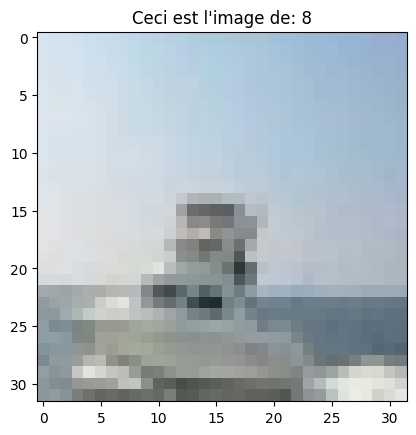

In [4]:
# Explorer le jeu de donnée
index_img = 100
plt.imshow(train_full.data[index_img,:,:])
plt.title('Ceci est l\'image de: '+str(train_full.targets[index_img]))

In [5]:
# Split train / validation
# Il faut noter ici que PyTorch ne produit pas une copie des données, mais extrait uniquement les indices pour le train_set 
# et les indices pour le validation set.
validation_split=0.2
n_total = len(train_full)         
n_val   = int(validation_split * n_total)             
n_train = n_total - n_val                 

train_set, val_set = random_split(
    train_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print(f'Train : {len(train_set)}  |  Validation : {len(val_set)}')

Train : 40000  |  Validation : 10000


In [6]:
# Choisir un nombre limité d'image pour votre entrainement (les 40000 images peuvent prendre
# trop de temps)

from torch.utils.data import Subset

num_train_img = 40000

# On prend les num_train_img premiers indices du train_set déjà splitté
train_set_reduit = Subset(
    train_set.dataset,
    train_set.indices[:num_train_img]
)

print(f'Train réduit : {len(train_set_reduit)}  |  Validation : {len(val_set)}')

Train réduit : 40000  |  Validation : 10000


### <font color='blue'> Definir une fonction utilitaire pour plotter l'historique de l'entrainement. </font>

In [7]:
# Une fonction qui va permettre de plotter la fonction de cout et la performance
def plot_training_history(history, save_fig=False, fig_name=''):
    # Plot training & validation accuracy values
    plt.figure()
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('accuracy' + fig_name + '.png')
    plt.show()

    plt.figure()
    # Plot training & validation loss values
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('loss' + fig_name+ '.png')
    plt.show()
    

### <font color='blue'> Definir une fonction utilitaire pour faire de la prediction avec le modèle </font>

In [8]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def model_predict(model, img: torch.Tensor, true_label: int) -> None:
    """
    Affiche une image CIFAR-10 et la prédiction du modèle.

    Paramètres
    ----------
    model      : nn.Module        — modèle entraîné
    img        : Tensor (3,32,32) — image issue du Dataset (format PyTorch CHW)
    true_label : int              — label correct
    """
    device = next(model.parameters()).device

    # Affichage
    # plt.imshow attend (H, W, C) — on permute les axes CHW → HWC
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

    # Prédiction
    # np.expand_dims(img, 0) → unsqueeze(0) : (3,32,32) → (1,3,32,32)
    model.eval()
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        y_hat  = logits.argmax(dim=1).item()

    print(f"The image is a      : {class_names[true_label]}")
    print(f"The model predicted : {class_names[y_hat]}")



### <font color='blue'> Definir une fonction utilitaire pour entrainer le modèle <font>

In [9]:
from torch.utils.data import DataLoader


def train_net(model, train_dataset, val_dataset,
              num_epochs, lr, batch_size,
              device=None,
              weight_decay=1e-6):
    """
    Entraîne un modèle PyTorch et retourne le modèle et l'historique.

    Paramètres
    ----------
    model         : nn.Module — modèle déjà instancié
    train_dataset : Dataset   — sous-ensemble d'entraînement
    val_dataset   : Dataset   — sous-ensemble de validation
    num_epochs    : int       — nombre d'époques
    lr            : float     — taux d'apprentissage (AdamW)
    batch_size    : int       — taille des mini-batches
    device        : torch.device | None — auto-détecté si None
    weight_decay  : float     — weight decay découplé (AdamW)

    Retours
    -------
    model   : nn.Module — modèle entraîné
    history : dict      — clés 'loss', 'accuracy', 'val_loss', 'val_accuracy'
    """

    # detecter et utiliser l'accelerateur pour votre machine
    if device == None:
        device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
    print(f"Using {device} device")
    model = model.to(device)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # Optimiseur et fonction de coût 
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    # Scheduler: Warmup → Cosine Decay ───────────────────────────────────────
    # LinearLR: scales LR from (start_factor × LR) up to (end_factor × LR)
    # i.e., 1e-6 → 1e-3 over WARMUP_EPOCHS
    EPOCHS = num_epochs
    WARMUP_EPOCHS = 0.2 * EPOCHS
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor = 1e-3,   # LR starts at 1e-3 × 1e-3 = 1e-6
        end_factor   = 1.0,    # LR ends at 1.0 × 1e-3 = 1e-3
        total_iters  = WARMUP_EPOCHS,
    )
    
    # CosineAnnealingLR: decays LR from LR_base down to eta_min following a cosine curve
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max  = EPOCHS - WARMUP_EPOCHS,  # number of decay epochs
        eta_min = 1e-6,
    )
    
    # SequentialLR chains both: switches from warmup to cosine at milestone WARMUP_EPOCHS
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers = [warmup_scheduler, cosine_scheduler],
        milestones = [WARMUP_EPOCHS],
    )

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    # Chaque pas d'entraînement comprent une étape d'entraînement et une étape de validation
    for epoch in range(EPOCHS):

        # Phase entraînement
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            correct      += (logits.argmax(dim=1) == y_batch).sum().item()
            total        += X_batch.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Phase validation
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits        = model(X_batch)
                val_loss_sum += criterion(logits, y_batch).item() * X_batch.size(0)
                val_correct  += (logits.argmax(dim=1) == y_batch).sum().item()
                val_total    += X_batch.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch {epoch+1:3d}/{num_epochs}  '
              f'loss={train_loss:.4f}  acc={train_acc:.4f}  '
              f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    return model, history

In [10]:
def evaluate(model: nn.Module, dataset,
             device=None, batch_size: int = 256) -> tuple:
    """
    Évalue un modèle sur un Dataset complet.
    Équivalent de model.evaluate() en Keras.

    Retourne (loss, accuracy).
    """
    if device is None:
        device = next(model.parameters()).device   # même device que le modèle

    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits      = model(X_batch)
            total_loss += criterion(logits, y_batch).item() * X_batch.size(0)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += X_batch.size(0)

    loss = total_loss / total
    acc  = correct   / total
    print(f'loss={loss:.4f}  accuracy={acc:.4f}')
    return loss, acc

### <font color='blue'> Definir un modèle MLP </font
                                                  

In [22]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron pour la classification MNIST.
    Architecture
    ------------
    Input (N, 28, 28) → Flatten → [Linear → ReLU] × 2 → Linear (logits)
    """

    def __init__(self, input_dim: int = 784, hidden_dims=[256, 128], num_classes: int = 10, dropout=0.2) -> None:
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))


In [23]:
# Visualiser le modèle
# Instanciation et affichage
sample_x, _ = train_set_reduit[0]          # (3, 32, 32) pour CIFAR-10
input_dim   = sample_x.numel()      # 3 × 32 × 32 = 3072

model_mlp = MLP(input_dim=input_dim, num_classes=10)
print(model_mlp)

n_params = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

Paramètres entraînables : 821,642


### <font color='blue'> Entrainer et tester le modèle. </font>

In [13]:
# Entrainer le modèle
nombre_epochs =500
batch_size = 32
lr = 0.001
mlp_trained, history= train_net(model_mlp, train_set_reduit, val_set, nombre_epochs, lr, batch_size, None) 

Using mps device
Epoch   1/500  loss=2.2836  acc=0.1475  val_loss=2.1545  val_acc=0.2403
Epoch   2/500  loss=2.1466  acc=0.2288  val_loss=2.0667  val_acc=0.2913
Epoch   3/500  loss=2.0815  acc=0.2633  val_loss=2.0114  val_acc=0.3168
Epoch   4/500  loss=2.0373  acc=0.2862  val_loss=1.9730  val_acc=0.3341
Epoch   5/500  loss=2.0014  acc=0.3062  val_loss=1.9450  val_acc=0.3524
Epoch   6/500  loss=1.9736  acc=0.3150  val_loss=1.9146  val_acc=0.3633
Epoch   7/500  loss=1.9484  acc=0.3307  val_loss=1.8917  val_acc=0.3721
Epoch   8/500  loss=1.9262  acc=0.3377  val_loss=1.8743  val_acc=0.3820
Epoch   9/500  loss=1.9111  acc=0.3434  val_loss=1.8562  val_acc=0.3875
Epoch  10/500  loss=1.8937  acc=0.3523  val_loss=1.8442  val_acc=0.3909
Epoch  11/500  loss=1.8777  acc=0.3629  val_loss=1.8269  val_acc=0.3950
Epoch  12/500  loss=1.8681  acc=0.3604  val_loss=1.8156  val_acc=0.3979
Epoch  13/500  loss=1.8539  acc=0.3692  val_loss=1.8055  val_acc=0.4020
Epoch  14/500  loss=1.8438  acc=0.3723  val_los

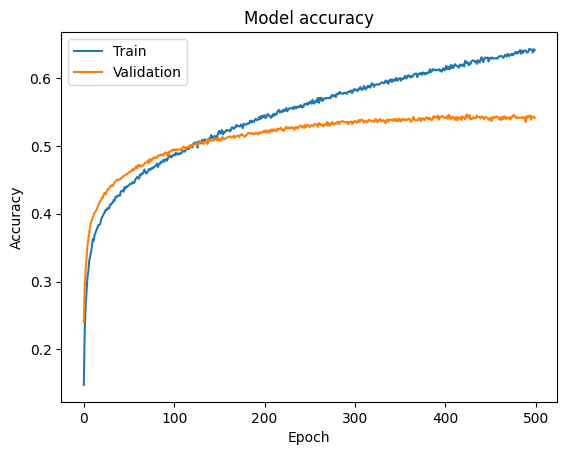

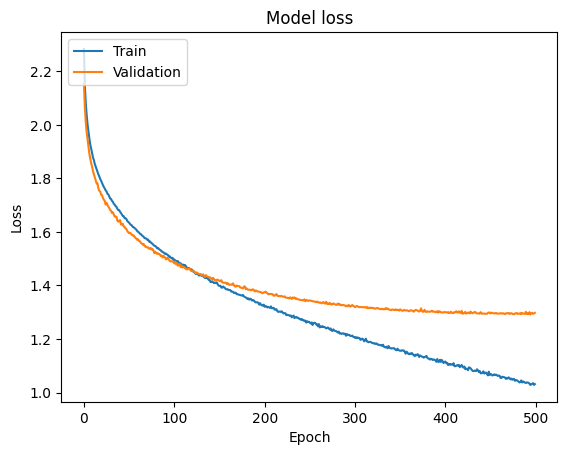

In [14]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût

plt.figure()
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('accuracy' + fig_name + '.png')
    plt.show()

    plt.figure()
    # Plot training & validation loss values
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('loss' + fig_name+ '.png')
    plt.show()

In [15]:
evaluate(mlp_trained, train_set_reduit)   # train réduit
evaluate(mlp_trained, train_full) # train complet
evaluate(mlp_trained, test_set)       # test

loss=0.7849  accuracy=0.7597
loss=0.8875  accuracy=0.7160
loss=1.2975  accuracy=0.5389


(1.297472114944458, 0.5389)

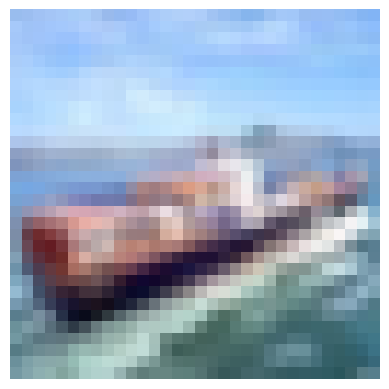

The image is a      : ship
The model predicted : ship


In [24]:
index_img = 2050
img, label = test_set[index_img]   # déballage correct : img (3,32,32) + label int
model_predict(mlp_trained, img, label)

### <font color='blue'> Definir un CNN

In [11]:
# premier modèle CNN
# Definir le model
class CNN_MODEL(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 input_size: tuple = (28, 28),
                 hidden_dims=[256, 128],
                 num_classes: int = 10,
                 dropout = 0.2) -> None:
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )

        # Inférence automatique de la taille aplatie
        # On fait passer un tenseur factice pour connaître la forme de sortie
        # sans avoir à la calculer à la main selon la résolution d'entrée.
        dummy = torch.zeros(1, in_channels, *input_size)
        flat_size = self.feature_extractor(dummy).numel()

        layers = []
        in_dim = flat_size
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x.flatten(1))
        return x

In [12]:
# Verifier le model
model_cnn = CNN_MODEL(in_channels=3, input_size= (32, 32))
print(model_cnn)

n_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

CNN_MODEL(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

Paramètres entraînables : 141,434


### <font color='blue'> Entrainer et evaluer le modèle </font>

In [17]:
# Entrainement du modèle
# Entrainer le modèle
nombre_epochs = 1000
batch_size = 40
lr = 0.001
cnn_trained, history_cnn= train_net(model_cnn, train_set_reduit, val_set, nombre_epochs, lr, batch_size, None) 

Using mps device
Epoch   1/1000  loss=1.1181  acc=0.5999  val_loss=1.1310  val_acc=0.5995
Epoch   2/1000  loss=1.1171  acc=0.6044  val_loss=1.1291  val_acc=0.6003
Epoch   3/1000  loss=1.1218  acc=0.5988  val_loss=1.1349  val_acc=0.5984
Epoch   4/1000  loss=1.1222  acc=0.5985  val_loss=1.1306  val_acc=0.5999
Epoch   5/1000  loss=1.1247  acc=0.6007  val_loss=1.1290  val_acc=0.6019
Epoch   6/1000  loss=1.1231  acc=0.6012  val_loss=1.1284  val_acc=0.6008
Epoch   7/1000  loss=1.1263  acc=0.6017  val_loss=1.1295  val_acc=0.6010
Epoch   8/1000  loss=1.1173  acc=0.6020  val_loss=1.1292  val_acc=0.5998
Epoch   9/1000  loss=1.1181  acc=0.6058  val_loss=1.1296  val_acc=0.6014
Epoch  10/1000  loss=1.1214  acc=0.6015  val_loss=1.1281  val_acc=0.6001
Epoch  11/1000  loss=1.1245  acc=0.5992  val_loss=1.1274  val_acc=0.6025
Epoch  12/1000  loss=1.1190  acc=0.6053  val_loss=1.1291  val_acc=0.6005
Epoch  13/1000  loss=1.1173  acc=0.6025  val_loss=1.1271  val_acc=0.6018
Epoch  14/1000  loss=1.1170  acc=0

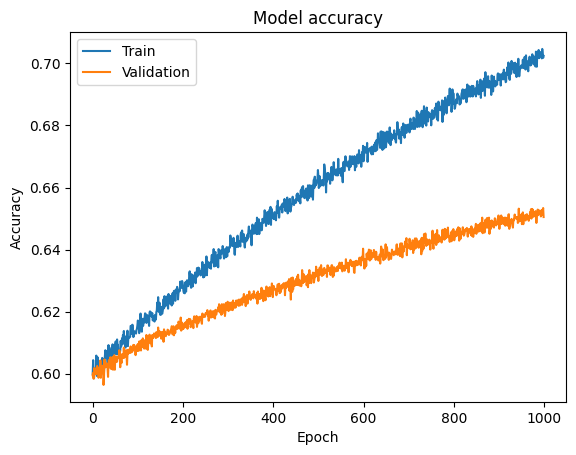

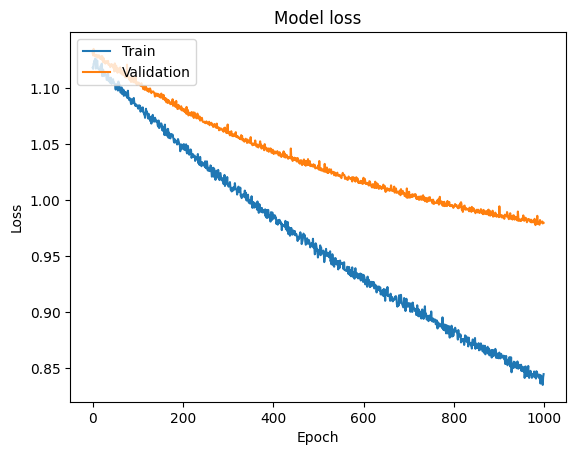

In [18]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
plot_training_history(history_cnn)

In [19]:
evaluate(cnn_trained, train_set_reduit)   # train réduit
evaluate(cnn_trained, train_full) # train complet
evaluate(cnn_trained, test_set)       # test

loss=0.6470  accuracy=0.7847
loss=0.7135  accuracy=0.7579
loss=0.9939  accuracy=0.6492


(0.993892479133606, 0.6492)